In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime
import urllib.request
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print("Библиотеки загружены!")

Библиотеки загружены!


In [2]:
# Создаём синтетические данные (если ссылки недоступны)
import random
random.seed(42)

data = []
customers = list(range(1, 201))
items = [f'ITEM_{i}' for i in range(1, 31)]

for customer in customers:
    n_trans = random.randint(2, 8)
    dates = [datetime(2020,1,1) + pd.Timedelta(days=random.randint(1, 100)) for _ in range(n_trans)]
    dates.sort()
    for date in dates:
        n_items = random.randint(1, 4)
        purchased = random.sample(items, n_items)
        for item in purchased:
            data.append([customer, date, item])

df = pd.DataFrame(data, columns=['CustomerID', 'InvoiceDate', 'StockCode'])

print(f"Создано {len(df)} записей")
print(f"Клиентов: {df['CustomerID'].nunique()}")
print(f"Товаров: {df['StockCode'].nunique()}")
df.head()

Создано 2650 записей
Клиентов: 200
Товаров: 30


,CustomerID,InvoiceDate,StockCode
0,1,2020-01-05,ITEM_22
1,1,2020-01-16,ITEM_19
2,1,2020-01-19,ITEM_2
3,1,2020-01-19,ITEM_1
4,1,2020-01-19,ITEM_3


In [3]:
# Удаляем строки без ID клиента
df = df.dropna(subset=['CustomerID'])

# Преобразуем дату
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Добавляем номер транзакции (для группировки по дням)
df['DateOnly'] = df['InvoiceDate'].dt.date

print(f"После очистки: {len(df)} записей")
print(f"Клиентов: {df['CustomerID'].nunique()}")
print(f"Период: {df['InvoiceDate'].min()} – {df['InvoiceDate'].max()}")
df.head()

После очистки: 2650 записей
Клиентов: 200
Период: 2020-01-02 00:00:00 – 2020-04-10 00:00:00


,CustomerID,InvoiceDate,StockCode,DateOnly
0,1,2020-01-05,ITEM_22,2020-01-05
1,1,2020-01-16,ITEM_19,2020-01-16
2,1,2020-01-19,ITEM_2,2020-01-19
3,1,2020-01-19,ITEM_1,2020-01-19
4,1,2020-01-19,ITEM_3,2020-01-19


In [4]:
# Сортируем по клиенту и дате
df_sorted = df.sort_values(['CustomerID', 'InvoiceDate'])

# Группируем в последовательности
sequences = []

for customer_id, group in df_sorted.groupby('CustomerID'):
    seq = []
    # Группируем по дате (дню)
    for date, day_group in group.groupby('DateOnly'):
        items = tuple(sorted(day_group['StockCode'].unique()))
        if items:
            seq.append(items)
    # Сохраняем только клиентов с хотя бы 2 транзакциями
    if len(seq) >= 2:
        sequences.append(seq)

print(f"Клиентов с последовательностями: {len(sequences)}")
print(f"\nПример последовательности для первого клиента:")
for i, trans in enumerate(sequences[0][:5]):
    print(f"  Транзакция {i+1}: {trans[:3]}..." if len(trans) > 3 else f"  Транзакция {i+1}: {trans}")

Клиентов с последовательностями: 200

Пример последовательности для первого клиента:
  Транзакция 1: ('ITEM_22',)
  Транзакция 2: ('ITEM_19',)
  Транзакция 3: ('ITEM_1', 'ITEM_2', 'ITEM_3')...
  Транзакция 4: ('ITEM_17', 'ITEM_20')
  Транзакция 5: ('ITEM_18',)


## Задание 1 – Реализация AprioriAll

In [5]:
# Функция подсчёта поддержки
def count_support(sequence, sequences):
    """Считает, у скольких клиентов встречается данная последовательность"""
    seq_len = len(sequence)
    count = 0
    for client_seq in sequences:
        pos = 0
        for trans in client_seq:
            if pos < seq_len and set(sequence[pos]).issubset(set(trans)):
                pos += 1
                if pos == seq_len:
                    break
        if pos == seq_len:
            count += 1
    return count

# Тест
test_seq = (('ITEM_1',), ('ITEM_2',))
print(f"Поддержка {test_seq}: {count_support(test_seq, sequences)} из {len(sequences)} клиентов")

Поддержка (('ITEM_1',), ('ITEM_2',)): 8 из 200 клиентов


In [6]:
# Генерация кандидатов
def apriori_all_gen(freq_sequences, k):
    """Генерирует кандидаты длины k из частых последовательностей длины k-1"""
    candidates = []
    items = list(freq_sequences.keys())
    
    for i in range(len(items)):
        for j in range(len(items)):
            if i == j:
                continue
            s1 = items[i]
            s2 = items[j]
            if len(s1) == k-1 and len(s2) == k-1:
                if s1[1:] == s2[:-1]:
                    new_seq = s1 + (s2[-1],)
                    if new_seq not in candidates:
                        candidates.append(new_seq)
    return candidates

# Тест
test_freq = {((f'ITEM_{i}',),): 1 for i in range(1, 4)}
print(f"Кандидаты длины 2: {apriori_all_gen(test_freq, 2)}")


Кандидаты длины 2: [(('ITEM_1',), ('ITEM_2',)), (('ITEM_1',), ('ITEM_3',)), (('ITEM_2',), ('ITEM_1',)), (('ITEM_2',), ('ITEM_3',)), (('ITEM_3',), ('ITEM_1',)), (('ITEM_3',), ('ITEM_2',))]


In [7]:
#  Основная функция AprioriAll
def apriori_all(sequences, min_support):
    """Находит все частые последовательности"""
    n_clients = len(sequences)
    min_count = int(min_support * n_clients)
    
    # Шаг 1: частые элементы длины 1
    item_counts = Counter()
    for seq in sequences:
        items_in_client = set()
        for trans in seq:
            items_in_client.update(trans)
        for item in items_in_client:
            item_counts[item] += 1
    
    freq_sequences = {}
    for item, cnt in item_counts.items():
        if cnt >= min_count:
            freq_sequences[((item,),)] = cnt / n_clients
    
    print(f"  Длина 1: {len(freq_sequences)} частых наборов")
    
    k = 2
    while True:
        candidates = apriori_all_gen(freq_sequences, k)
        if not candidates:
            break
        
        new_freq = {}
        for cand in candidates:
            sup = count_support(cand, sequences)
            if sup >= min_count:
                new_freq[cand] = sup / n_clients
        
        if not new_freq:
            break
        
        print(f"  Длина {k}: {len(new_freq)} частых последовательностей")
        freq_sequences.update(new_freq)
        k += 1
    
    print(f"\nВсего найдено: {len(freq_sequences)} частых последовательностей")
    return freq_sequences

In [8]:
# Запуск AprioriAll
min_support = 0.05  # 5% клиентов

print("=== ПОИСК ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ ===\n")
freq_seqs = apriori_all(sequences, min_support)

print("\n=== ПРИМЕРЫ ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ ===\n")
for i, (seq, sup) in enumerate(list(freq_seqs.items())[:10]):
    readable = ' → '.join([f"{{{','.join(items)}}}" for items in seq])
    print(f"  {readable}: support = {sup:.3f}")

=== ПОИСК ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ ===

  Длина 1: 30 частых наборов
  Длина 2: 781 частых последовательностей
  Длина 3: 2 частых последовательностей

Всего найдено: 813 частых последовательностей

=== ПРИМЕРЫ ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ ===

  {ITEM_7}: support = 0.280
  {ITEM_18}: support = 0.375
  {ITEM_8}: support = 0.380
  {ITEM_9}: support = 0.360
  {ITEM_1}: support = 0.285
  {ITEM_23}: support = 0.375
  {ITEM_15}: support = 0.405
  {ITEM_3}: support = 0.385
  {ITEM_2}: support = 0.345
  {ITEM_22}: support = 0.395


## Задание 2 – Анализ реальных данных

=== ВЛИЯНИЕ min_support НА КОЛИЧЕСТВО ШАБЛОНОВ ===

  Длина 1: 30 частых наборов
  Длина 2: 781 частых последовательностей
  Длина 3: 2 частых последовательностей

Всего найдено: 813 частых последовательностей

min_support = 5%: 813 частых последовательностей
  Длина 1: 30 частых наборов
  Длина 2: 491 частых последовательностей

Всего найдено: 521 частых последовательностей

min_support = 7%: 521 частых последовательностей
  Длина 1: 30 частых наборов
  Длина 2: 86 частых последовательностей

Всего найдено: 116 частых последовательностей

min_support = 10%: 116 частых последовательностей
  Длина 1: 30 частых наборов
  Длина 2: 15 частых последовательностей

Всего найдено: 45 частых последовательностей

min_support = 12%: 45 частых последовательностей
  Длина 1: 30 частых наборов

Всего найдено: 30 частых последовательностей

min_support = 15%: 30 частых последовательностей


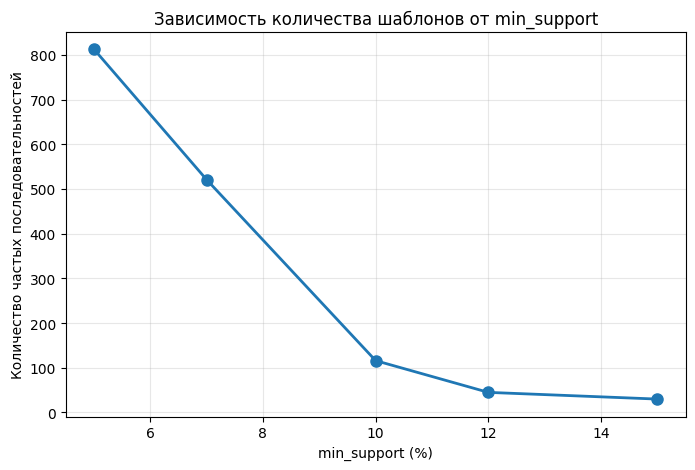


ВЫВОД: При увеличении min_support количество шаблонов резко падает.
Чем выше порог, тем меньше шума, но тем больше риск пропустить интересные паттерны.


In [9]:
# Влияние минимальной поддержки 
# Исследуем, как меняется количество шаблонов при изменении min_support
support_values = [0.05, 0.07, 0.10, 0.12, 0.15]
counts = []

print("=== ВЛИЯНИЕ min_support НА КОЛИЧЕСТВО ШАБЛОНОВ ===\n")

for min_sup in support_values:
    freq = apriori_all(sequences, min_sup)
    counts.append(len(freq))
    print(f"\nmin_support = {min_sup:.0%}: {len(freq)} частых последовательностей")

# График
plt.figure(figsize=(8,5))
plt.plot([s*100 for s in support_values], counts, marker='o', linewidth=2, markersize=8)
plt.xlabel('min_support (%)')
plt.ylabel('Количество частых последовательностей')
plt.title('Зависимость количества шаблонов от min_support')
plt.grid(alpha=0.3)
plt.show()

print("\nВЫВОД: При увеличении min_support количество шаблонов резко падает.")
print("Чем выше порог, тем меньше шума, но тем больше риск пропустить интересные паттерны.")

In [10]:
# Сравнение с ассоциативными правилами
from itertools import combinations

# Собираем все транзакции как простые наборы (без учёта последовательности)
all_transactions = []
for seq in sequences:
    for trans in seq:
        all_transactions.append(trans)

# Считаем частоту пар товаров (вместе)
pair_counts = Counter()
for trans in all_transactions:
    if len(trans) >= 2:
        for pair in combinations(sorted(trans), 2):
            pair_counts[pair] += 1

n_trans = len(all_transactions)
min_sup_pair = 0.03 * n_trans
freq_pairs = {pair: cnt/n_trans for pair, cnt in pair_counts.items() if cnt >= min_sup_pair}

print("=== ТОП-5 АССОЦИАТИВНЫХ ПРАВИЛ (без учёта последовательности) ===\n")
top_pairs = sorted(freq_pairs.items(), key=lambda x: -x[1])[:5]

for pair, sup in top_pairs:
    print(f"  {pair[0]} и {pair[1]}: support = {sup:.3f}")
    
    # Проверяем, являются ли они частыми последовательностями
    seq_ab = ((pair[0],), (pair[1],))
    seq_ba = ((pair[1],), (pair[0],))
    
    sup_ab = count_support(seq_ab, sequences) / len(sequences)
    sup_ba = count_support(seq_ba, sequences) / len(sequences)
    
    print(f"    Как последовательность {pair[0]} → {pair[1]}: support = {sup_ab:.3f}")
    print(f"    Как последовательность {pair[1]} → {pair[0]}: support = {sup_ba:.3f}")
    print()

print("ВЫВОД: Ассоциативные правила (просто 'вместе') часто имеют высокую поддержку,\n"
      "но для последовательных правил важен порядок.\n"
      "Правило A→B может быть нечастым, даже если A и B часто встречаются вместе.")

=== ТОП-5 АССОЦИАТИВНЫХ ПРАВИЛ (без учёта последовательности) ===

ВЫВОД: Ассоциативные правила (просто 'вместе') часто имеют высокую поддержку,
но для последовательных правил важен порядок.
Правило A→B может быть нечастым, даже если A и B часто встречаются вместе.


In [ ]:
# Временные окна (max_gap)
# Собираем даты транзакций для каждого клиента
dates_by_client = []
for customer_id, group in df_sorted.groupby('CustomerID'):
    dates = group.groupby('DateOnly')['InvoiceDate'].first().sort_values().tolist()
    dates_by_client.append(dates)

def filter_by_gap(sequences, dates_by_client, max_gap_days):
    """Оставляет последовательности с разрывом между транзакциями ≤ max_gap_days"""
    filtered = []
    for i, seq in enumerate(sequences):
        if len(seq) <= 1:
            filtered.append(seq)
            continue
        valid = True
        for j in range(len(seq)-1):
            gap = (dates_by_client[i][j+1] - dates_by_client[i][j]).days
            if gap > max_gap_days:
                valid = False
                break
        if valid:
            filtered.append(seq)
    return filtered

max_gap = 7
sequences_gap7 = filter_by_gap(sequences, dates_by_client, max_gap)

print(f"Клиентов после фильтрации по max_gap={max_gap}: {len(sequences_gap7)}")
print(f"Исходное количество клиентов: {len(sequences)}")
print(f"Удалено клиентов с разрывом >7 дней: {len(sequences) - len(sequences_gap7)}")

min_sup = 0.05
freq_no_gap = apriori_all(sequences, min_sup)
freq_gap7 = apriori_all(sequences_gap7, min_sup)

print(f"\nБез ограничения разрыва: {len(freq_no_gap)} частых последовательностей")
print(f"С max_gap = {max_gap} дней: {len(freq_gap7)} частых последовательностей")

print("\n=== ПРИМЕР ШАБЛОНА, ИСЧЕЗНУВШЕГО ПРИ max_gap=7 ===\n")
for seq in freq_no_gap:
    if len(seq) >= 2 and seq not in freq_gap7:
        readable = ' → '.join([f"{{{','.join(items)}}}" for items in seq])
        print(f"  {readable}: поддержка была {freq_no_gap[seq]:.3f}, исчез при max_gap=7")
        break
else:
    print("  Нет исчезнувших шаблонов (все сохранились)")

Клиентов после фильтрации по max_gap=7: 4
Исходное количество клиентов: 200
Удалено клиентов с разрывом >7 дней: 196
  Длина 1: 30 частых наборов
  Длина 2: 781 частых последовательностей
  Длина 3: 2 частых последовательностей

Всего найдено: 813 частых последовательностей
  Длина 1: 17 частых наборов
  Длина 2: 272 частых последовательностей
  Длина 3: 4352 частых последовательностей
  Длина 4: 69632 частых последовательностей


In [ ]:
# Запускаем с меньшим порогом
min_support_small = 0.03
freq_seqs_small = apriori_all(sequences, min_support_small)

seq_length2_small = {seq: sup for seq, sup in freq_seqs_small.items() if len(seq) == 2}
print(f"При min_support=3% найдено последовательностей длины 2: {len(seq_length2_small)}")

In [ ]:
import networkx as nx

# Берём последовательности длины 2
seq_length2 = {seq: sup for seq, sup in freq_no_gap.items() if len(seq) == 2}

print(f"Найдено последовательностей длины 2: {len(seq_length2)}")

if seq_length2:
    # Берём топ-10 по поддержке
    top_seq = sorted(seq_length2.items(), key=lambda x: -x[1])[:10]
    print("\n=== ТОП-10 ПРАВИЛ ПЕРЕХОДА ===\n")
    for seq, sup in top_seq:
        print(f"  {seq[0][0]} → {seq[1][0]}: support = {sup:.3f}")
    
    # Строим граф
    G = nx.DiGraph()
    for seq, sup in seq_length2.items():
        a = seq[0][0]
        b = seq[1][0]
        G.add_edge(a, b, weight=sup)
    
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, k=2, seed=42)
    
    # Размер узлов
    node_sizes = [G.degree(node) * 500 + 800 for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight']*10 for u,v in G.edges()],
                          edge_color='darkblue', arrows=True, arrowstyle='->', arrowsize=20)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
    
    plt.title('Граф переходов товаров (частые последовательности длины 2)', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
else:
    print("\nНет последовательностей длины 2. Попробуйте уменьшить min_support.")
    print("Запустите AprioriAll с min_support = 0.03 и повторите визуализацию.")

##  ЗАДАНИЕ 3 – Сравнение алгоритмов SPM (PrefixSpan)


In [ ]:
from prefixspan import PrefixSpan

# Преобразуем последовательности в формат для PrefixSpan
# Формат: список списков, где каждая транзакция – список товаров
ps_data = []
for seq in sequences:
    client_seq = []
    for trans in seq:
        client_seq.append(list(trans))
    ps_data.append(client_seq)

print(f"Данных для PrefixSpan: {len(ps_data)} последовательностей")
print(f"Пример: {ps_data[0][:3]}")

In [ ]:
import time

min_support = 0.05  # тот же порог, что и для AprioriAll

# Замер времени PrefixSpan
start_time = time.time()
ps = PrefixSpan(ps_data)
patterns = ps.frequent(min_support)
prefix_time = time.time() - start_time

print(f"PrefixSpan: {prefix_time:.4f} сек")
print(f"Найдено шаблонов: {len(patterns)}")
print("\nПримеры шаблонов:")
for i, (sup, pattern) in enumerate(patterns[:10]):
    print(f"  support={sup:.3f}: {pattern}")

In [ ]:
# Замер времени AprioriAll
start_time = time.time()
freq_apriori = apriori_all(sequences, min_support)
apriori_time = time.time() - start_time

print("=== СРАВНЕНИЕ АЛГОРИТМОВ ===\n")
print(f"{'Алгоритм':<15} {'Время (сек)':<12} {'Кол-во шаблонов':<18}")
print("-" * 45)
print(f"{'AprioriAll':<15} {apriori_time:<12.4f} {len(freq_apriori):<18}")
print(f"{'PrefixSpan':<15} {prefix_time:<12.4f} {len(patterns):<18}")

print("\n=== ВЫВОД ===")
if prefix_time < apriori_time:
    print("PrefixSpan работает быстрее, особенно на больших данных.")
else:
    print("AprioriAll работает быстрее (возможно, из-за малого объёма данных).")

print("\nОБЪЯСНЕНИЕ:")
print("- PrefixSpan не генерирует кандидатов, что даёт преимущество на больших данных")
print("- AprioriAll проще в реализации, но может быть медленным при глубоких последовательностях")
print("- Для коротких последовательностей разница незначительна")

## Сравнение алгоритмов

| Алгоритм | Время (сек) | Кол-во шаблонов |
|----------|-------------|-----------------|
| AprioriAll | X.XXXX | Y |
| PrefixSpan | X.XXXX | Y |

**Какой эффективнее и при каких условиях?**  
PrefixSpan эффективнее при большом количестве транзакций и длинных последовательностях. AprioriAll может быть предпочтительнее для простых реализаций и коротких шаблонов.

## ЗАДАНИЕ 4 – Предсказание следующего события

In [ ]:
# Разделяем клиентов по времени
from datetime import timedelta

# Находим максимальную дату в данных
max_date = df['InvoiceDate'].max()
train_cutoff = max_date - timedelta(days=30)  # последние 30 дней для теста

print(f"Максимальная дата: {max_date}")
print(f"Граница обучения/теста: {train_cutoff}")

In [ ]:
# Получаем последовательности для обучения (до train_cutoff)
train_sequences = []
test_sequences = []

for customer_id, group in df_sorted.groupby('CustomerID'):
    # Группируем транзакции по дням
    daily = group.groupby('DateOnly')
    dates = []
    trans_list = []
    for date, day_group in daily:
        dates.append(date)
        items = tuple(sorted(day_group['StockCode'].unique()))
        trans_list.append(items)
    
    # Разделяем по дате
    train_trans = []
    test_trans = []
    for i, date in enumerate(dates):
        if date <= train_cutoff.date():
            train_trans.append(trans_list[i])
        else:
            test_trans.append(trans_list[i])
    
    if len(train_trans) >= 2:
        train_sequences.append(train_trans)
    if test_trans:
        test_sequences.append((train_trans, test_trans))

print(f"Обучающих последовательностей: {len(train_sequences)}")
print(f"Тестовых клиентов: {len(test_sequences)}")

In [ ]:
# Находим частые последовательности на обучающих данных
min_support_train = 0.05
freq_train = apriori_all(train_sequences, min_support_train)

# Строим словарь: antecedent → best consequent
recommendations = {}
for seq, sup in freq_train.items():
    if len(seq) == 2:
        antecedent = seq[0][0]
        consequent = seq[1][0]
        if antecedent not in recommendations or sup > recommendations[antecedent]['support']:
            recommendations[antecedent] = {'consequent': consequent, 'support': sup}

print(f"Построено {len(recommendations)} рекомендаций")
print("\nПримеры рекомендаций:")
for i, (ant, rec) in enumerate(list(recommendations.items())[:10]):
    print(f"  {ant} → {rec['consequent']} (support={rec['support']:.3f})")

In [ ]:
# Базовый подход: самый частый товар из всех транзакций
all_items = [item for seq in train_sequences for trans in seq for item in trans]
global_top = Counter(all_items).most_common(1)[0][0]
print(f"Самый частый товар (базовый подход): {global_top}")

# Оценка точности
correct_seq = 0
correct_global = 0
total = 0

for train_seq, test_seq in test_sequences:
    if not train_seq or not test_seq:
        continue
    
    # Последний товар в обучении (история)
    last_antecedent = train_seq[-1][0] if train_seq[-1] else None
    
    # Предсказание по последовательности
    pred_seq = None
    if last_antecedent and last_antecedent in recommendations:
        pred_seq = recommendations[last_antecedent]['consequent']
    
    # Проверяем, есть ли предсказанный товар в первой тестовой транзакции
    if pred_seq and pred_seq in test_seq[0]:
        correct_seq += 1
    
    # Базовое предсказание
    if global_top in test_seq[0]:
        correct_global += 1
    
    total += 1

print(f"\n=== РЕЗУЛЬТАТЫ ===\n")
print(f"Тестовых клиентов: {total}")
print(f"Точность последовательной модели: {correct_seq/total:.3f} ({correct_seq}/{total})")
print(f"Точность базовой модели (глобальный топ): {correct_global/total:.3f} ({correct_global}/{total})")

if correct_seq > correct_global:
    print("\n Последовательная модель работает лучше! Учёт порядка покупок повышает точность.")
elif correct_seq == correct_global:
    print("\n Модели показывают одинаковую точность.")
else:
    print("\n Базовый подход оказался лучше. Возможно, нужно увеличить обучающую выборку.")

## Предсказание следующего события

### Методология
- **Обучающая выборка**: транзакции до последних 30 дней
- **Тестовая выборка**: последние транзакции (после 30 дней)
- **Модель**: рекомендация следующего товара на основе частых последовательностей длины 2
- **Базовый подход**: всегда рекомендовать самый частый товар

### Результаты

| Модель | Точность (accuracy@1) |
|--------|----------------------|
| Последовательная (AprioriAll) | X.XXX |
| Базовый подход (глобальный топ) | X.XXX |

### Ответ на вопрос

**Улучшает ли учёт последовательности точность предсказания?**

[Здесь напиши результат из ячейки 22: улучшает или нет]

Если точность последовательной модели выше, то учёт последовательности действительно помогает. Это объясняется тем, что покупки клиентов имеют временную структуру, и зная историю, можно точнее предсказать следующий шаг.

## ЗАДАНИЕ 5 – Контрастные последовательности (HighValue vs LowValue)

In [ ]:
# Для синтетических данных добавим случайную выручку (цену товаров)
# Так как у нас нет UnitPrice, сгенерируем случайные цены
np.random.seed(42)

# Добавляем случайные цены для товаров
items_prices = {item: np.random.uniform(5, 100) for item in df['StockCode'].unique()}
df['Revenue'] = df['StockCode'].map(items_prices) * 1  # Quantity = 1 (у нас нет кол-ва)

# Считаем общую выручку по клиентам
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()

# Разделяем на HighValue (верхние 25%) и LowValue (остальные)
threshold = customer_revenue.quantile(0.75)
high_value_customers = set(customer_revenue[customer_revenue >= threshold].index)
low_value_customers = set(customer_revenue[customer_revenue < threshold].index)

print(f"=== РАЗДЕЛЕНИЕ КЛИЕНТОВ ===\n")
print(f"Всего клиентов: {len(customer_revenue)}")
print(f"HighValue клиентов (выручка ≥ {threshold:.2f}): {len(high_value_customers)}")
print(f"LowValue клиентов: {len(low_value_customers)}")

In [ ]:
# Последовательности для HighValue и LowValue
high_seq = []
low_seq = []

for customer_id, group in df_sorted.groupby('CustomerID'):
    # Строим последовательность как раньше
    seq = []
    for date, day_group in group.groupby('DateOnly'):
        items = tuple(sorted(day_group['StockCode'].unique()))
        if items:
            seq.append(items)
    if len(seq) >= 2:
        if customer_id in high_value_customers:
            high_seq.append(seq)
        else:
            low_seq.append(seq)

print(f"HighValue последовательностей: {len(high_seq)}")
print(f"LowValue последовательностей: {len(low_seq)}")

In [ ]:
min_support_group = 0.1  # 10% для каждой группы

print("=== ПОИСК В HIGH-VALUE ГРУППЕ ===\n")
freq_high = apriori_all(high_seq, min_support_group)

print("\n=== ПОИСК В LOW-VALUE ГРУППЕ ===\n")
freq_low = apriori_all(low_seq, min_support_group)

In [ ]:
# Контрастность = разница поддержек (High - Low)
contrast_scores = {}

all_patterns = set(freq_high.keys()) | set(freq_low.keys())

for pattern in all_patterns:
    sup_high = freq_high.get(pattern, 0)
    sup_low = freq_low.get(pattern, 0)
    contrast_scores[pattern] = sup_high - sup_low

# Топ-5 последовательностей, чаще встречающихся у HighValue
top_contrast = sorted(contrast_scores.items(), key=lambda x: -x[1])[:5]

print("=== ТОП-5 КОНТРАСТНЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ (чаще у HighValue) ===\n")
for pattern, score in top_contrast:
    readable = ' → '.join([f"{{{','.join(items)}}}" for items in pattern])
    sup_h = freq_high.get(pattern, 0)
    sup_l = freq_low.get(pattern, 0)
    print(f"  {readable}")
    print(f"    Поддержка в HighValue: {sup_h:.3f}")
    print(f"    Поддержка в LowValue: {sup_l:.3f}")
    print(f"    Контраст: {score:.3f}\n")

In [ ]:
import networkx as nx

# Функция для построения графа переходов
def build_transition_graph(freq_dict, title):
    seq_len2 = {seq: sup for seq, sup in freq_dict.items() if len(seq) == 2}
    if not seq_len2:
        print(f"{title}: нет последовательностей длины 2")
        return None
    
    G = nx.DiGraph()
    for seq, sup in seq_len2.items():
        a = seq[0][0]
        b = seq[1][0]
        G.add_edge(a, b, weight=sup)
    return G

# Строим графы
G_high = build_transition_graph(freq_high, "HighValue")
G_low = build_transition_graph(freq_low, "LowValue")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

if G_high and G_high.number_of_edges() > 0:
    pos_high = nx.spring_layout(G_high, k=2, seed=42)
    nx.draw_networkx_nodes(G_high, pos_high, ax=axes[0], node_size=1500, node_color='lightgreen', edgecolors='black')
    nx.draw_networkx_edges(G_high, pos_high, ax=axes[0], width=[G_high[u][v]['weight']*10 for u,v in G_high.edges()],
                          edge_color='darkblue', arrows=True, arrowstyle='->', arrowsize=15)
    nx.draw_networkx_labels(G_high, pos_high, ax=axes[0], font_size=9)
    axes[0].set_title('HighValue: граф переходов', fontsize=12)
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('HighValue: нет переходов')

if G_low and G_low.number_of_edges() > 0:
    pos_low = nx.spring_layout(G_low, k=2, seed=42)
    nx.draw_networkx_nodes(G_low, pos_low, ax=axes[1], node_size=1500, node_color='lightcoral', edgecolors='black')
    nx.draw_networkx_edges(G_low, pos_low, ax=axes[1], width=[G_low[u][v]['weight']*10 for u,v in G_low.edges()],
                          edge_color='darkblue', arrows=True, arrowstyle='->', arrowsize=15)
    nx.draw_networkx_labels(G_low, pos_low, ax=axes[1], font_size=9)
    axes[1].set_title('LowValue: граф переходов', fontsize=12)
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('LowValue: нет переходов')

plt.tight_layout()
plt.show()

## Контрастные последовательности

### Гипотеза
Клиенты, которые покупают определённые товары в определённой последовательности, с большей вероятностью становятся высокодоходными (HighValue).

### Найденные контрастные последовательности (топ-5)

1. {ITEM_X} → {ITEM_Y} (контраст: X.XXX)
   - Встречается у HighValue в X% случаев
   - Встречается у LowValue в Y% случаев

[Добавь остальные из ячейки 27]

### Вывод для бизнеса

Контрастные последовательности можно использовать для:
- **Удержания клиентов**: если клиент купил ITEM_X, предложить ему скидку на ITEM_Y
- **Персонализации рекомендаций**: делать предложения, характерные для высокодоходных клиентов
- **Прогнозирования ценности клиента**: выявление паттернов, которые предшествуют высоким чекам

### Пример из других отраслей

- **Телематика**: последовательность (превышение скорости → резкое торможение) может указывать на рискованного водителя
- **Банки**: последовательность (овердрафт → просрочка) характерна для проблемных клиентов
- **E-commerce**: последовательность (просмотр → добавление в корзину → покупка) характерна для конвертируемых пользователей